In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load CSV data Files
sales = pd.read_csv('purchase_behaviour.csv')
transc = pd.read_csv('transaction_data.csv')

In [4]:
#Inspect data
sales.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [5]:
# Summary of Data
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [6]:
# Check for any null values
# Found zero null values

sales.isnull().sum()

LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

In [7]:
# Customers for each premium_customer Category
sales.groupby(['PREMIUM_CUSTOMER'])['LYLTY_CARD_NBR'].count().sort_values(ascending=False)

PREMIUM_CUSTOMER
Mainstream    29245
Budget        24470
Premium       18922
Name: LYLTY_CARD_NBR, dtype: int64

In [8]:
# Lifstage count for each category
sales.groupby(['LIFESTAGE'])['LYLTY_CARD_NBR'].count().sort_values(ascending=False)

LIFESTAGE
RETIREES                  14805
OLDER SINGLES/COUPLES     14609
YOUNG SINGLES/COUPLES     14441
OLDER FAMILIES             9780
YOUNG FAMILIES             9178
MIDAGE SINGLES/COUPLES     7275
NEW FAMILIES               2549
Name: LYLTY_CARD_NBR, dtype: int64

In [9]:
transc.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [10]:
# Summary of data
transc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB


In [11]:
# Check for any null values
# Found zero null values
transc.isnull().sum()

DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64

<Axes: >

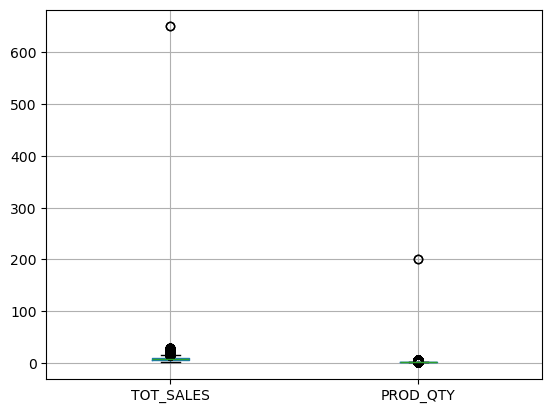

In [12]:
# Find outliers and remove them
transc.boxplot(column=['TOT_SALES','PROD_QTY'])

In [13]:
# Find index of ouliers and remove them
outliers = transc.loc[(transc['TOT_SALES'] > 100) | (transc['PROD_QTY'] > 100)]
transc.drop(outliers.index,inplace=True)

In [14]:
# Convert serial date to normal Date Format

transc['DATE']  = pd.to_datetime(transc['DATE'],origin='1900-01-01',unit='D')
transc['DATE']

0        2018-10-19
1        2019-05-16
2        2019-05-22
3        2018-08-19
4        2018-08-20
            ...    
264831   2019-03-11
264832   2018-08-15
264833   2018-11-08
264834   2018-12-29
264835   2018-09-24
Name: DATE, Length: 264834, dtype: datetime64[ns]

In [15]:
transc.head(5)

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,2018-10-19,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,2019-05-16,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,2019-05-22,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,2018-08-19,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,2018-08-20,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [16]:
# Split brand name and pack size

import re

number = re.compile(r'\d+g')

transc['PACK_SIZE'] = transc['PROD_NAME'].apply(lambda x: int(number.findall(x)[0].strip('g') if number.findall(x) else 0))
transc['PACK_SIZE']

0         175
1         175
2         170
3         175
4         150
         ... 
264831    175
264832    175
264833    170
264834    150
264835    175
Name: PACK_SIZE, Length: 264834, dtype: int64

In [17]:
transc['BRAND_NAME'] = transc['PROD_NAME'].apply(lambda x: " ".join(x.split()[:-1]))
transc['BRAND_NAME']

0                         Natural Chip Compny
1                            CCs Nacho Cheese
2            Smiths Crinkle Cut Chips Chicken
3            Smiths Chip Thinly S/Cream&Onion
4         Kettle Tortilla ChpsHny&Jlpno Chili
                         ...                 
264831     Kettle Sweet Chilli And Sour Cream
264832                Tostitos Splash Of Lime
264833                       Doritos Mexicana
264834     Doritos Corn Chip Mexican Jalapeno
264835                Tostitos Splash Of Lime
Name: BRAND_NAME, Length: 264834, dtype: object

In [18]:
## Arrange columns in order
transc = transc[['DATE','STORE_NBR','LYLTY_CARD_NBR','TXN_ID','PROD_NBR','BRAND_NAME','PACK_SIZE','PROD_QTY','TOT_SALES']]

In [19]:
transc.head(5)

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,BRAND_NAME,PACK_SIZE,PROD_QTY,TOT_SALES
0,2018-10-19,1,1000,1,5,Natural Chip Compny,175,2,6.0
1,2019-05-16,1,1307,348,66,CCs Nacho Cheese,175,3,6.3
2,2019-05-22,1,1343,383,61,Smiths Crinkle Cut Chips Chicken,170,2,2.9
3,2018-08-19,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion,175,5,15.0
4,2018-08-20,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili,150,3,13.8


In [20]:
transc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 264834 entries, 0 to 264835
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   DATE            264834 non-null  datetime64[ns]
 1   STORE_NBR       264834 non-null  int64         
 2   LYLTY_CARD_NBR  264834 non-null  int64         
 3   TXN_ID          264834 non-null  int64         
 4   PROD_NBR        264834 non-null  int64         
 5   BRAND_NAME      264834 non-null  object        
 6   PACK_SIZE       264834 non-null  int64         
 7   PROD_QTY        264834 non-null  int64         
 8   TOT_SALES       264834 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(6), object(1)
memory usage: 20.2+ MB


In [21]:
# Merge two Data Frames to extract insights

sales_data = pd.merge(sales,transc,on='LYLTY_CARD_NBR')

In [22]:
# Feature Inspection 
sales_data.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER,DATE,STORE_NBR,TXN_ID,PROD_NBR,BRAND_NAME,PACK_SIZE,PROD_QTY,TOT_SALES
0,1000,YOUNG SINGLES/COUPLES,Premium,2018-10-19,1,1,5,Natural Chip Compny,175,2,6.0
1,1002,YOUNG SINGLES/COUPLES,Mainstream,2018-09-18,1,2,58,Red Rock Deli Chikn&Garlic Aioli,150,1,2.7
2,1003,YOUNG FAMILIES,Budget,2019-03-09,1,3,52,Grain Waves Sour Cream&Chives,0,1,3.6
3,1003,YOUNG FAMILIES,Budget,2019-03-10,1,4,106,Natural ChipCo Hony Soy,175,1,3.0
4,1004,OLDER SINGLES/COUPLES,Mainstream,2018-11-04,1,5,96,WW Original Stacked Chips,160,1,1.9


In [23]:
# Summary of merged Data
sales_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264834 entries, 0 to 264833
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   LYLTY_CARD_NBR    264834 non-null  int64         
 1   LIFESTAGE         264834 non-null  object        
 2   PREMIUM_CUSTOMER  264834 non-null  object        
 3   DATE              264834 non-null  datetime64[ns]
 4   STORE_NBR         264834 non-null  int64         
 5   TXN_ID            264834 non-null  int64         
 6   PROD_NBR          264834 non-null  int64         
 7   BRAND_NAME        264834 non-null  object        
 8   PACK_SIZE         264834 non-null  int64         
 9   PROD_QTY          264834 non-null  int64         
 10  TOT_SALES         264834 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(6), object(3)
memory usage: 22.2+ MB


In [24]:
# Total Sales for Premium_customer Category

premium_purchase = sales_data.groupby(['PREMIUM_CUSTOMER'])['TOT_SALES'].sum().sort_values(ascending=False)
premium_purchase


PREMIUM_CUSTOMER
Mainstream    750744.50
Budget        676211.55
Premium       506158.95
Name: TOT_SALES, dtype: float64

In [25]:
# Create columns for Day and Month.
sales_data["DAY_OF_WEEK"] = sales_data['DATE'].dt.dayofweek
sales_data["MONTH"] = sales_data['DATE'].dt.month

In [26]:
# Total Sales for Day of week
sales_data.groupby(['DAY_OF_WEEK'])["TOT_SALES"].sum().sort_values(ascending=False)

DAY_OF_WEEK
1    282579.10
6    279521.30
4    277876.40
0    275612.60
2    274315.95
5    272565.65
3    270644.00
Name: TOT_SALES, dtype: float64

In [27]:
# Total Sales for each Month 
sales_data.groupby(['MONTH'])["TOT_SALES"].sum().sort_values(ascending=False)

MONTH
12    167907.40
3     166521.80
7     165278.10
10    164979.70
1     162737.10
6     160287.40
9     159876.70
11    159839.50
4     159625.00
8     158632.85
5     156798.95
2     150630.50
Name: TOT_SALES, dtype: float64

In [28]:
# Popular Brands by Total sales

popular_brands = sales_data.groupby(['BRAND_NAME'])['TOT_SALES'].sum().sort_values(ascending=False)[:10]
popular_brands

BRAND_NAME
Dorito Corn Chp Supreme                39052.0
Smiths Crnkle Chip Orgnl Big Bag       36367.6
Smiths Crinkle Chips Salt & Vinegar    34804.2
Kettle Mozzarella Basil & Pesto        34457.4
Smiths Crinkle Original                34302.6
Cheezels Cheese                        34296.9
Doritos Cheese Supreme                 33390.6
Kettle Sweet Chilli And Sour Cream     33031.8
Kettle Original                        32740.2
Kettle Sea Salt And Vinegar            32589.0
Name: TOT_SALES, dtype: float64

In [31]:
# Most sold Pack Sizes

sales_data.groupby(['PACK_SIZE'])['PROD_QTY'].sum().sort_values(ascending=False)[:10]

PACK_SIZE
175    123692
150     79330
134     48019
110     42835
170     38088
165     29051
300     28813
330     23999
380     12273
270     12049
Name: PROD_QTY, dtype: int64

In [32]:
# Sales by LIFESTAGE
sales_by_segment = sales_data.groupby("LIFESTAGE")["TOT_SALES"].sum().sort_values(ascending=False).reset_index()
sales_by_segment

,LIFESTAGE,TOT_SALES
0,OLDER SINGLES/COUPLES,402426.75
1,RETIREES,366470.90
2,OLDER FAMILIES,352467.20
3,YOUNG FAMILIES,316160.10
4,YOUNG SINGLES/COUPLES,260405.30
5,MIDAGE SINGLES/COUPLES,184751.30
6,NEW FAMILIES,50433.45


In [33]:
# Loyal Customers to our store
customers_frq = sales_data.groupby('LYLTY_CARD_NBR')['TXN_ID'].count().sort_values(ascending=False).reset_index()
customers_frq.columns = ['LYLTY_CARD_NBR','FREQUENCY']
customers_frq

,LYLTY_CARD_NBR,FREQUENCY
0,172032,18
1,162039,18
2,13138,17
3,230078,17
4,116181,17
...,...,...
72631,143033,1
72632,143029,1
72633,143027,1
72634,143026,1


In [65]:
# Popular Brands by PROD_QTY
Top_products = sales_data.groupby(['BRAND_NAME'])['TOT_SALES'].sum().sort_values(ascending=False)[:3].reset_index(0)
Top_products

,BRAND_NAME,TOT_SALES
0,Dorito Corn Chp Supreme,39052.0
1,Smiths Crnkle Chip Orgnl Big Bag,36367.6
2,Smiths Crinkle Chips Salt & Vinegar,34804.2


In [59]:
# Identify loyal customers by counting the number of transactions per loyalty card
loyalty_counts = sales_data.groupby('LYLTY_CARD_NBR')['TXN_ID'].nunique().reset_index(name='txn_count')

# Get the maximum transaction count
max_txn = loyalty_counts['txn_count'].max()

# Consider customers with max txn count as most loyal
most_loyal_customers = loyalty_counts[loyalty_counts['txn_count'] == max_txn]

print('Most Loyal Customers:')
most_loyal_customers



Most Loyal Customers:


,LYLTY_CARD_NBR,txn_count
42813,162039,18


In [64]:
# Characteristics of most loyal customers: since we only have the loyalty card number, we can hypothesize they are frequent buyers and they likely purchase products for which they are loyal.
# We then look into what products these loyal customers are buying. We'll filter df for these customers.

loyal_customer_ids = most_loyal_customers['LYLTY_CARD_NBR'].unique()
loyal_customer_transactions = sales_data[sales_data['LYLTY_CARD_NBR'].isin(loyal_customer_ids)]

# Analyze products bought by loyal customers
loyal_product_sales = loyal_customer_transactions.groupby(['PROD_NBR', 'BRAND_NAME'], as_index=False)['TOT_SALES'].sum()

print('Products purchased by most loyal customers:')
print(loyal_product_sales.sort_values('TOT_SALES', ascending=False).reset_index(0))


Products purchased by most loyal customers:
    index  PROD_NBR                           BRAND_NAME  TOT_SALES
0       1        16  Smiths Crinkle Chips Salt & Vinegar       11.4
1      15       102      Kettle Mozzarella Basil & Pesto       10.8
2      12        89   Kettle Sweet Chilli And Sour Cream       10.8
3       9        71               Twisties Cheese Burger        8.6
4      17       112        Tyrrells Crisps Ched & Chives        8.4
5       5        42   Doritos Corn Chip Mexican Jalapeno        7.8
6       3        31    Infzns Crn Crnchers Tangy Gcamole        7.6
7       2        24             Grain Waves Sweet Chilli        7.2
8      10        78           Thins Chips Salt & Vinegar        6.6
9       6        45      Smiths Thinly Cut Roast Chicken        6.0
10      7        53        RRD Sweet Chilli & Sour Cream        6.0
11     16       106              Natural ChipCo Hony Soy        6.0
12     14       100             Smiths Crinkle Cut Chips        5.8
13  

## Insights

##   Top 3 most profitable products
 

###  1. Dorito Corn Chp Supreme	
### 2. Smiths Crnkle Chip Orgnl Big Bag	
### 3. Smiths Crinkle Chips Salt & Vinegar

### Hypothesis: Loyal customers may appreciate consistent quality, value for money, and products that match their personal tastes. They might be particularly drawn to products that provide both convenience and reliability, which drives repeated purchases over time.')
